# Прогнозирование сумм платежей с помощью catboost (+ SARIMAX)

Прогнозируем суммы платежей в различных формах - суммы платежей суммарно на следующие день/неделю/месяц, также с группировкой по различным описательным признакам (фонды, провайдеры платежей, тип подписки, категории платежей).

На **текущем этапе** данные подготовлены для прогнозирования сумм исходя из описательных признаков c учетом временной составляющей с применением трех моделей: LSTM, SARIMAX, Catboost и последующим взвешиванием прогнозов.

<a id='К-содержанию'></a>
**Содержание проекта** 
- [Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)
- [Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей](#Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей)
- [LSTM](#LSTM-подготовка-данных)  
    - [Подготовка данных](#LSTM-подготовка-данных)  
    - [Построение и обучение модели](#LSTM-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#LSTM-валидация-модели-с-визуализацией-прогноза)  
- [SARIMAX](#SARIMAX-подготовка-данных)  
    - [Подготовка данных](#SARIMAX-подготовка-данных)  
    - [Построение и обучение модели](#SARIMAX-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#SARIMAX-валидация-модели-с-визуализацией-прогноза)  
- [Catboost (+sarimax)](#Catboost-подготовка-данных)  
    - [Подготовка данных](#Catboost-подготовка-данных)  
    - [Построение и обучение модели](#Catboost-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#Catboost-валидация-модели-с-визуализацией-прогноза)
- [Подбор модели ансамбля прогнозов на валидационной выборке](#Подбор-модели-ансамбля-прогнозов-на-валидационной-выборке)
- [Тестирование ансамбля прогнозов на тестовой выборке](#Тестирование-ансамбля-прогнозов-на-тестовой-выборке)


In [1]:
%%capture
!pip install torch

In [2]:
#импортируем библиотеки перед началом проекта одним блоком
import os
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# загружаем класс pipeline и классы дя подготовки данных и запуска пайплайна
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from tqdm import notebook
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# загружаем нужные модели и метрики
from catboost import CatBoostRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

# загружаем библиотеки для Pytorch и предобученных моделей
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)

# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

def smape(y_true, y_pred):
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

# cоздаём метрику smape
smape_scorer = make_scorer(smape, greater_is_better=False)

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [4]:
# импортируем тренировочные данные
pth1 = 'data.csv'

if os.path.exists(pth1):
    data = pd.read_csv(pth1)
else:
    print('Something is wrong')

data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360258 entries, 0 to 360257
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   fund_id     360258 non-null  int64  
 1   full_sum    360258 non-null  float64
 2   date        360258 non-null  int64  
 3   provider    360258 non-null  int64  
 4   signup      360258 non-null  int64  
 5   category_1  360258 non-null  int64  
 6   category_2  360258 non-null  int64  
 7   category_3  360258 non-null  int64  
 8   category_4  360258 non-null  int64  
 9   category_5  360258 non-null  int64  
 10  category_6  360258 non-null  int64  
 11  category_7  360258 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 33.0 MB


,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7
0,44,500.00,1508393717,4,0,0,0,0,0,0,0,0
1,88,200.00,1508399528,4,0,0,0,0,0,0,0,0
2,1,100.00,1508400025,4,0,0,0,0,0,0,0,0
3,1,100.00,1508400043,4,0,0,0,0,0,0,0,0
4,1,20.00,1508400088,4,0,0,0,0,0,0,0,0


In [5]:
# посмотрим распределение меток по категориям
cat_columns = ['category_1', 'category_2', 'category_3', 'category_4', 'category_5', 'category_6', 'category_7']

data['cat_columns_sum'] = data[cat_columns].sum(axis=1)
display(data['cat_columns_sum'].value_counts())

data = data.drop(['cat_columns_sum'],axis=1)

cat_columns_sum
0    321861
1     21656
2     10219
3      6522
Name: count, dtype: int64

In [6]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())

# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

# уберем дубликаты и пропуски
data = data.drop_duplicates()
data = data.dropna()

Количество дубликатов:  2989
Количество пропусков:  0


In [7]:
# исключаем мегавыбросы (платежи более порога TRESHOLD_CONST) 
# для более адекватного обучения модели 

TRESHOLD_CONST = 0.95

threshold = data['full_sum'].quantile(TRESHOLD_CONST)
data = data[data['full_sum']<=threshold]

Выловили порядка 3 тысяч дубликатов, что с одной стороны маловероятно - одинаковые платежи в одну и ту же секунду, но, возможно, банк обработал платежи одним пакетом, с точки зрения обучения дубликаты не несут дополнительной информации, поэтому их удалили.  
Выбросы на суммы платежей более порога 95%-перцентиля рублей также исключили.


In [8]:
# по датам добавим столбец в наглядном формате datetime
data['datetime'] = pd.to_datetime(data['date'], unit='s')
data = data.drop('date', axis=1)

data.head() 

,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
0,44,500.00,4,0,0,0,0,0,0,0,0,2017-10-19 06:15:17
1,88,200.00,4,0,0,0,0,0,0,0,0,2017-10-19 07:52:08
2,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:25
3,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:43
4,1,20.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:01:28


<a id='Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей'></a> 
## Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей
[К содержанию](#К-содержанию)

In [9]:
# выберем фонд
data_fund = data[data['fund_id']==136].copy() #136

data_fund.info()
data_fund.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3924 entries, 527 to 360131
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fund_id     3924 non-null   int64         
 1   full_sum    3924 non-null   float64       
 2   provider    3924 non-null   int64         
 3   signup      3924 non-null   int64         
 4   category_1  3924 non-null   int64         
 5   category_2  3924 non-null   int64         
 6   category_3  3924 non-null   int64         
 7   category_4  3924 non-null   int64         
 8   category_5  3924 non-null   int64         
 9   category_6  3924 non-null   int64         
 10  category_7  3924 non-null   int64         
 11  datetime    3924 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 398.5 KB


,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
527,136,100.00,5,1,0,0,1,0,0,0,0,2017-10-20 09:47:44
708,136,200.00,1,1,0,0,1,0,0,0,0,2017-10-20 14:40:08
15185,136,200.00,1,1,0,0,1,0,0,0,0,2017-11-02 14:19:13
15535,136,400.00,1,0,0,0,1,0,0,0,0,2017-11-02 22:45:43
16267,136,1000.00,1,0,0,0,1,0,0,0,0,2017-11-03 17:35:34


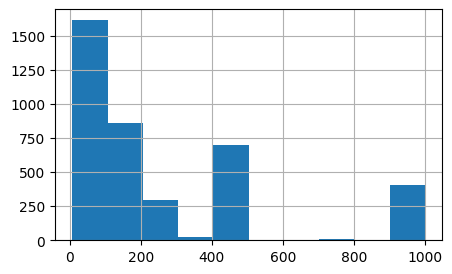

In [10]:
data_fund['full_sum'].hist(bins=10,figsize=(5, 3));

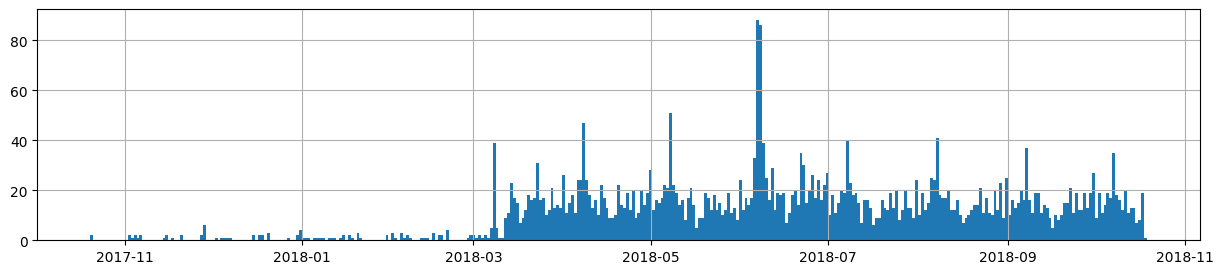

In [11]:
data_fund['datetime'].dt.date.hist(bins=365, figsize=(15, 3));

In [12]:
data_fund = data_fund.drop('fund_id', axis=1)
#data_fund = data_fund.drop('provider', axis=1)
#data_fund = data_fund.drop(['category_1', 'category_2','category_3', 'category_4', 'category_5', 'category_6', 'category_7'], axis=1) # признаки с нулевым влиянием - исключаем

# проверяем монотонность и сортируем при необходимости
if not data_fund['datetime'].is_monotonic_increasing:
    data_fund = data_fund.sort_values('datetime')

data_fund.head(1)

,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
527,100.00,5,1,0,0,1,0,0,0,0,2017-10-20 09:47:44


In [13]:
# функция  агрегации и добавления признаков
def agg_add_features_data_fund(data, rolling_window=2):
        
        data = data.copy()
        
        # добавляем столбец с датой
        data['date'] = data['datetime'].dt.floor('D')  # сохраняем формат datetime64[ns]
        

        # перед агрегацией заполняем пропуски нулевыми строками
        date_range = pd.date_range(start=data['date'].min(), end=data['date'].max())
        data_full = pd.DataFrame({'date': date_range})
        # объединяем исходные данные с полным списком дат
        data = data_full.merge(data, on='date', how='left')
        # для datetime используем значение из date
        data['datetime'] = data['datetime'].fillna(data['date'])
        # остальные столбцы заполняем нулями
        numeric_columns = data.columns.difference(['date', 'datetime'])
        data[numeric_columns] = data[numeric_columns].fillna(0)
        

        # добавляем столбцы с днем недели и номером недели в месяце
        data['day_of_week'] = data['datetime'].dt.weekday.astype('str')
        #data['week_number'] = data_fund['datetime'].dt.isocalendar().week.astype('str')  # номер недели в году, не очень актуально
        data['week_number'] = data['datetime'].dt.day.sub(1).floordiv(7).add(1) # номер недели в месяце

        
        # кодируем признак 'provider'
        enc = OneHotEncoder(drop='first', sparse=False)
        encoded_provider = enc.fit_transform(data[['provider']])
        # переводим в датафейм и объединяем с исходными данными
        encoded_df = pd.DataFrame(encoded_provider, columns=enc.get_feature_names_out(['provider']), index=data.index)
        data = pd.concat([data.drop(columns=['provider']), encoded_df], axis=1)
        

        # определяем список столбцов для агрегации (все, кроме группировочного и временных)
        columns_to_aggregate = data.columns.difference(['date','datetime','day_of_week', 'week_number'])

        # делаем агрегацию исходных данных
        aggregated_data = data.groupby('date')[columns_to_aggregate].sum()
        aggregated_data.index.name = None

        # генерируем доппризнаки
        added_features = data.groupby('date').agg(
        count_payments=('full_sum', 'count'),  # количество платежей
        avg_payment=('full_sum', 'mean'),  # средний размер платежа
        median_payment=('full_sum', 'median'),  # медианный платеж
        min_payment=('full_sum', 'min'),  # минимальный платеж
        max_payment=('full_sum', 'max'),  # максимальный платеж
        day_of_week=('day_of_week', 'first'),  # день недели
        week_number=('week_number', 'first')  # номер недели
        )
        added_features.index.name = None
        
        # добавим скользящее среднее по платежам за последние n дней (например, 7 дней), исключая текущий день
        added_features['rolling_avg_payment'] = (added_features['avg_payment'].shift(1)
                                                 .rolling(window=rolling_window, min_periods=1)
                                                 .mean()
                                                 )
        #  посчитаем скользящее стандартное отклонение платежей за последние rolling_window дней (исключая текущий день)
        #added_features['rolling_std_payment'] = (added_features['avg_payment'].shift(1)
        #                                 .rolling(window=rolling_window, min_periods=1)
        #                                 .std()
        #                                 )
        
        # cредняя выручка за аналогичный день недели за последний месяц (4 недели)
        #added_features['weekday_avg_revenue'] = (added_features.groupby(added_features.index.dayofweek)['avg_payment']
        #                                 .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()))

        # добавляем лаги на 1-7 дней
        for lag in range(1, 8):
                added_features[f'lag_{lag}_full_sum'] = aggregated_data['full_sum'].shift(lag)

        # объединяем aggregated_data и added_features по индексу
        final_data = aggregated_data.join(added_features, how='left')

        # корректируем счетчик платежей, т.к. выше добавляли пустые строки для заполнения пропущенных дат, 
        # и чтобы "нулевые" суммы не считались платежами
        final_data['count_payments'] = final_data.apply(lambda x: 0 if x['full_sum'] == 0 else x['count_payments'], axis=1)

        return final_data

# преобразовываем датасет
data_fund_added_agg = agg_add_features_data_fund(data_fund)

display(data_fund_added_agg.shape,
        data_fund_added_agg.head(2))



(365, 28)

,category_1,category_2,category_3,category_4,category_5,category_6,category_7,full_sum,provider_1.0,provider_3.0,provider_4.0,provider_5.0,signup,count_payments,avg_payment,median_payment,min_payment,max_payment,day_of_week,week_number,rolling_avg_payment,lag_1_full_sum,lag_2_full_sum,lag_3_full_sum,lag_4_full_sum,lag_5_full_sum,lag_6_full_sum,lag_7_full_sum
2017-10-20,0.00,0.00,2.00,0.00,0.00,0.00,0.00,300.00,1.00,0.00,0.00,1.00,2.00,2,150.00,150.00,100.00,200.00,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-10-21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,5,3,150.00,300.00,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# посмотрим сколько пропусков осталось после агрегации
data_fund_added_agg.isna().sum().sum()

29

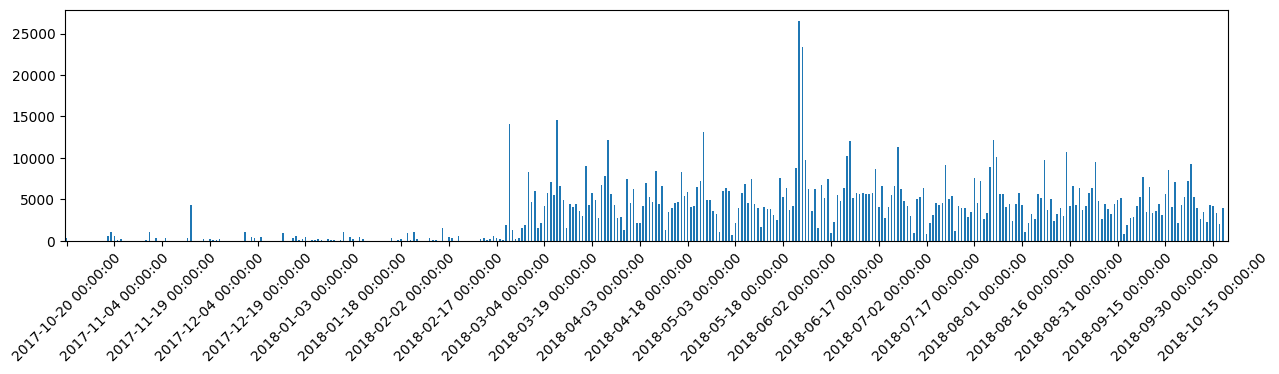

In [15]:
ax = data_fund_added_agg['full_sum'].plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  #настраиваем подписи на оси x
plt.xticks(rotation=45)

plt.show()

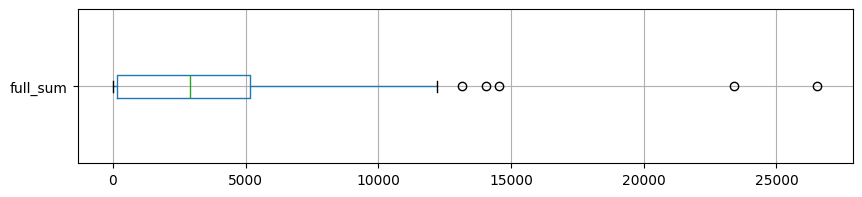

In [16]:
data_fund_added_agg[['full_sum']].boxplot(figsize=(10, 2), vert=False);

In [17]:
# заменяем агрегированные дневные суммы из THRESHOLD_CONST перцентиля на медианное значение
threshold = data_fund_added_agg['full_sum'].quantile(TRESHOLD_CONST)
print(threshold)
median_full_sum = data_fund_added_agg['full_sum'].median()
print(median_full_sum)
data_fund_added_agg.loc[data_fund_added_agg['full_sum'] > threshold, 'full_sum'] = median_full_sum

8919.200000000003
2901.0


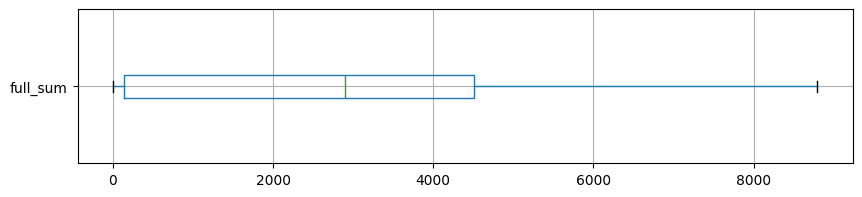

In [18]:
data_fund_added_agg[['full_sum']].boxplot(figsize=(10, 2), vert=False);

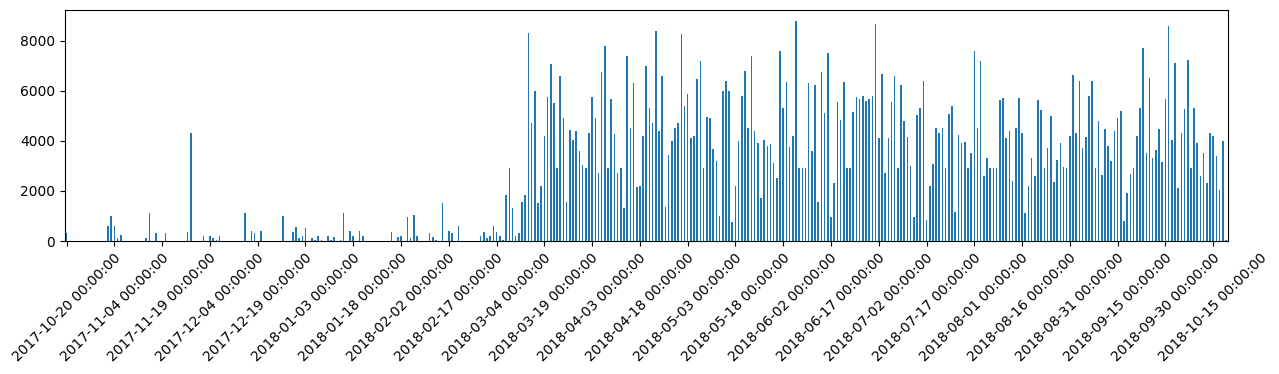

In [19]:
ax = data_fund_added_agg['full_sum'].plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  # настрраиваем подписи по оси X
plt.xticks(rotation=45)

plt.show()

In [20]:
# сбросим строки с пропусками, которые образовались после агрегации и добавлении признаков
final_data_fund = data_fund_added_agg.dropna().copy()

In [21]:
# сдвигаем целевую переменную на 1 назад, чтобы модель училась предсказывать по текущему значению признаков будущий день
# актуально для всех моделей кроме SARIMAX
final_data_fund_shifted = final_data_fund.copy()
final_data_fund_shifted['target_shifted'] = final_data_fund_shifted['full_sum'].shift(-1)

# убираем последнюю строку, так как она становится NaN из-за сдвига
final_data_fund_shifted = final_data_fund_shifted[:-1]

In [22]:
# определяем последние два месяца в данных для валидации и тестирования
test_month = final_data_fund_shifted.index.max().strftime('%Y-%m')  # последний год-месяц
val_month = (final_data_fund_shifted.index.max() - pd.DateOffset(months=1)).strftime('%Y-%m')  # предпоследний год-месяц

# разделяем данные
final_train_data_fund = final_data_fund_shifted.loc[final_data_fund_shifted.index < val_month]
final_val_data_fund = final_data_fund_shifted.loc[final_data_fund_shifted.index.strftime('%Y-%m') == val_month]
final_test_data_fund = final_data_fund_shifted.loc[final_data_fund_shifted.index.strftime('%Y-%m') == test_month]

# проверяем размеры и даты
display(final_train_data_fund.shape, final_val_data_fund.shape, final_test_data_fund.shape)

print("Последняя тренировочная дата:", final_train_data_fund.index.max().date())
print("Первая валидационная дата:", final_val_data_fund.index.min().date())
print("Последняя валидационная дата:", final_val_data_fund.index.max().date())
print("Первая тестовая дата:", final_test_data_fund.index.min().date())

(309, 29)

(30, 29)

(18, 29)

Последняя тренировочная дата: 2018-08-31
Первая валидационная дата: 2018-09-01
Последняя валидационная дата: 2018-09-30
Первая тестовая дата: 2018-10-01


In [23]:
# выделяем категоральные признаки
cat_features = ['day_of_week', 'week_number']

# формируем X_train и y_train
X_train = final_train_data_fund.drop(['full_sum', 'target_shifted'], axis=1)
y_train = final_train_data_fund['target_shifted']

# формируем X_val и y_val
X_val = final_val_data_fund.drop(['full_sum', 'target_shifted'], axis=1)
y_val = final_val_data_fund['target_shifted']

# формируем X_test и y_test
X_test = final_test_data_fund.drop(['full_sum','target_shifted'], axis=1) 
y_test = final_test_data_fund['target_shifted']

## LSTM
### Подготовка данных
<a id='LSTM-подготовка-данных'></a> 
[К содержанию](#К-содержанию)

In [24]:
# масштабируем числовые признаки
scaler_x = StandardScaler()
X_train_num_scaled = scaler_x.fit_transform(X_train.drop(columns=cat_features))
X_val_num_scaled = scaler_x.transform(X_val.drop(columns=cat_features))
X_test_num_scaled = scaler_x.transform(X_test.drop(columns=cat_features))

# кодируем категориальные признаки
X_train_cat_encoded = pd.get_dummies(X_train[cat_features], dtype=float)
X_val_cat_encoded = pd.get_dummies(X_val[cat_features], dtype=float)
X_test_cat_encoded = pd.get_dummies(X_test[cat_features], dtype=float)

# Выравниваем столбцы (если в тестовой или валидационной выборке пропущены категории)
X_train_cat_encoded, X_val_cat_encoded = X_train_cat_encoded.align(X_val_cat_encoded, join='left', axis=1, fill_value=0)
X_train_cat_encoded, X_test_cat_encoded = X_train_cat_encoded.align(X_test_cat_encoded, join='left', axis=1, fill_value=0)
X_val_cat_encoded, X_test_cat_encoded = X_val_cat_encoded.align(X_test_cat_encoded, join='left', axis=1, fill_value=0)

# объединяем обратно
X_train_prepared = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_val_prepared = np.hstack([X_val_num_scaled, X_val_cat_encoded])
X_test_prepared = np.hstack([X_test_num_scaled, X_test_cat_encoded])

# масштабируем целевую переменную
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# преобразуем обратно в DataFrame для сохранения временных индексов
X_train_prepared = pd.DataFrame(
    X_train_prepared, 
    columns=list(X_train.drop(columns=cat_features).columns) + list(X_train_cat_encoded.columns),
    index=X_train.index)

X_val_prepared = pd.DataFrame(
    X_val_prepared,
    columns=list(X_val.drop(columns=cat_features).columns) + list(X_val_cat_encoded.columns),
    index=X_val.index)

X_test_prepared = pd.DataFrame(
    X_test_prepared, 
    columns=list(X_test.drop(columns=cat_features).columns) + list(X_test_cat_encoded.columns),
    index=X_test.index)

# преобразуем в Series(см.выше)
y_train_scaled = pd.Series(y_train_scaled.ravel(), name=y_train.name, index=y_train.index)
y_val_scaled = pd.Series(y_val_scaled.ravel(), name=y_val.name, index=y_val.index)
y_test_scaled = pd.Series(y_test_scaled.ravel(), name=y_test.name, index=y_test.index)

<a id='LSTM-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [25]:

# задаем шаги и количество разбиений временного ряда
time_steps = 7
n_splits = 10

# функция создания последовательностей для LSTM
def create_sequences(data, target, time_steps=1):
    X_seq, y_seq = [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i + time_steps])
        y_seq.append(target[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

# создаем последовательности
X_seq, y_seq = create_sequences(X_train_prepared, y_train_scaled, time_steps)

# делим данные последовательно для временного ряда
tss = TimeSeriesSplit(n_splits=n_splits)
rmse_scores_train = []
rmse_scores_test = []
smape_scores_train = []
smape_scores_test = []

for train_idx, test_idx in tss.split(X_seq):
    X_train_s, X_test_s = X_seq[train_idx], X_seq[test_idx]
    y_train_s, y_test_s = y_seq[train_idx], y_seq[test_idx]

    # конвертируем данные в тензоры для pytorch
    X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_s, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_s, dtype=torch.float32).view(-1, 1)

    # фомируем модель LSTM
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, output_size):
            super(LSTMModel, self).__init__()
            self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
            #self.dropout1 = nn.Dropout(0.1)
            #self.lstm2 = nn.LSTM(hidden_size, hidden_size, batch_first=True)
            #self.dropout2 = nn.Dropout(0.2)
            self.fc1 = nn.Linear(hidden_size, 256)
            self.fc2 = nn.Linear(256, output_size)

        def forward(self, x):
            x, _ = self.lstm1(x)
            #x = self.dropout1(x)
            #x, _ = self.lstm2(x)
            #x = self.dropout2(x)
            x = x[:, -1, :]
            x = self.fc1(x)
            x = torch.relu(x)
            x = self.fc2(x)
            return x

        
    # инициализация модели
    input_size = X_train_s.shape[2]
    hidden_size = 256
    output_size = 1
    model_lstm = LSTMModel(input_size, hidden_size, output_size)

    # задаем функцию потерь и оптимизатор
    #criterion = nn.MSELoss()
    criterion = nn.HuberLoss(delta=1.5)
    optimizer = optim.AdamW(model_lstm.parameters(), lr=0.001, weight_decay=1e-4)

    # создаем ReduceLROnPlateau
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # обучение модели
    num_epochs = 100
    for epoch in range(num_epochs):
        model_lstm.train()
        optimizer.zero_grad()
        output = model_lstm(X_train_tensor)
        loss = criterion(output, y_train_tensor)
        loss.backward()
        optimizer.step()

        # вычисление RMSE и SMAPE на тренировочных данных
        if (epoch + 1) % 10 == 0:
            # разворачиваем масштабированные значения
            y_train_original = scaler_y.inverse_transform(y_train_tensor.detach().numpy().reshape(-1, 1))
            y_train_pred_original = scaler_y.inverse_transform(output.detach().numpy().reshape(-1, 1))

            # вычисление RMSE и SMAPE на развернутых данных
            train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
            train_smape = smape(y_train_original, y_train_pred_original)
            #print(f"Эпоха [{epoch + 1}/{num_epochs}], Потеря: {loss.item():.4f}, RMSE (train): {train_rmse:.4f}, SMAPE (train): {train_smape:.4f}")
    
    # Вызываем ReduceLROnPlateau
    scheduler.step(loss)  # передаем loss для отслеживания

    # вычисление RMSE и SMAPE на тестовых данных после обучения
    model_lstm.eval()
    with torch.no_grad():
        y_pred = model_lstm(X_test_tensor)
        
        # разворачиваем масштабированные прогнозы
        y_test_original = scaler_y.inverse_transform(y_test_tensor.numpy().reshape(-1, 1))
        y_pred_original = scaler_y.inverse_transform(y_pred.numpy().reshape(-1, 1))

        # вычисление RMSE и SMAPE на развернутых данных
        test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        test_smape = smape(y_test_original, y_pred_original)
        #print(f"RMSE на тестовых данных: {test_rmse:.4f}, SMAPE на тестовых данных: {test_smape:.4f}  \n")

    rmse_scores_train.append(train_rmse)
    rmse_scores_test.append(test_rmse)
    smape_scores_train.append(train_smape)
    smape_scores_test.append(test_smape)


# выводим средние метрики RMSE и SMAPE для всех фолдов
print(f"Средний RMSE на тренировочных данных: {np.mean(rmse_scores_train):.4f}, Средний SMAPE на тренировочных данных: {np.mean(smape_scores_train):.4f}")
print(f"Средний RMSE на тестовых данных: {np.mean(rmse_scores_test):.4f}, Средний SMAPE на тестовых данных: {np.mean(smape_scores_test):.4f}")

/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_74269/471584127.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(target[i + time_steps])


Средний RMSE на тренировочных данных: 541.3496, Средний SMAPE на тренировочных данных: 117.6031
Средний RMSE на тестовых данных: 1691.5203, Средний SMAPE на тестовых данных: 85.9814


<a id='LSTM-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [26]:
# формируем последовательности
X_seq_full, y_seq_full = create_sequences(X_train_prepared, y_train_scaled, time_steps)

# преобразуем в тензоры
X_full_tensor = torch.tensor(X_seq_full, dtype=torch.float32)
y_full_tensor = torch.tensor(y_seq_full, dtype=torch.float32).view(-1, 1)

# обучаем модель на всем тренировочном датасете
for epoch in range(num_epochs):
    model_lstm.train()
    optimizer.zero_grad()
    output = model_lstm(X_full_tensor)
    loss = criterion(output, y_full_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        y_full_original = scaler_y.inverse_transform(y_full_tensor.detach().numpy().reshape(-1, 1))
        y_full_pred_original = scaler_y.inverse_transform(output.detach().numpy().reshape(-1, 1))
        full_rmse = np.sqrt(mean_squared_error(y_full_original, y_full_pred_original))
        full_smape = smape(y_full_original, y_full_pred_original)
        print(f"Эпоха [{epoch + 1}/{num_epochs}], Потеря: {loss.item():.4f}, RMSE: {full_rmse:.4f}, SMAPE: {full_smape:.4f}")

Эпоха [10/100], Потеря: 0.0506, RMSE: 792.0499, SMAPE: 69.0929


/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_74269/471584127.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(target[i + time_steps])


Эпоха [20/100], Потеря: 0.0372, RMSE: 679.0278, SMAPE: 67.5559
Эпоха [30/100], Потеря: 0.0279, RMSE: 588.0835, SMAPE: 65.9655
Эпоха [40/100], Потеря: 0.0230, RMSE: 533.2766, SMAPE: 64.7794
Эпоха [50/100], Потеря: 0.0176, RMSE: 466.4836, SMAPE: 64.7241
Эпоха [60/100], Потеря: 0.0140, RMSE: 416.6266, SMAPE: 63.2785
Эпоха [70/100], Потеря: 0.0119, RMSE: 383.2683, SMAPE: 62.5828
Эпоха [80/100], Потеря: 0.0122, RMSE: 388.0111, SMAPE: 62.2740
Эпоха [90/100], Потеря: 0.0095, RMSE: 343.0030, SMAPE: 61.2109
Эпоха [100/100], Потеря: 0.0085, RMSE: 324.7652, SMAPE: 60.2731


In [27]:
# добавляем последние time_steps строк из тренировочного набора в валидационный набор
# (тк они нужны для запуска первого прогноза, чтобы не тратить на это валидационные данные)
X_val_full = pd.concat([X_train_prepared.tail(time_steps), X_val_prepared], axis=0)
y_val_full = pd.concat([y_train_scaled.tail(time_steps), y_val_scaled], axis=0)

# создаем последовательности для тестового набора
X_seq_val, y_seq_val = create_sequences(X_val_full.values, y_val_full.values, time_steps)

# преобразуем в тензоры
X_val_tensor = torch.tensor(X_seq_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_seq_val, dtype=torch.float32).view(-1, 1)

# делаем прогноз
model_lstm.eval()
with torch.no_grad():
    y_pred = model_lstm(X_val_tensor)

# разворачиваем масштабированные данные
y_val_original = np.round(scaler_y.inverse_transform(y_val_tensor.numpy()).flatten(), decimals=2)
y_val_pred_lstm = np.round(scaler_y.inverse_transform(y_pred.numpy()).flatten(), decimals=2)

# преобразуем y_val_original в Series с правильными временныеми индексами
y_val_original = pd.Series(y_val_original, index=y_val_full.index[-len(y_val_original):])

# считаем метрики
rmse_val_lstm = np.sqrt(mean_squared_error(y_val_original, y_val_pred_lstm))
smape_val_lstm = smape(y_val_original, y_val_pred_lstm)

print(f'Метрика RMSE на валидационных данных: {rmse_val_lstm:.3f}')
print(f'Метрика SMAPE на валидационных данных: {smape_val_lstm:.4f}')

Метрика RMSE на валидационных данных: 2516.296
Метрика SMAPE на валидационных данных: 49.7603


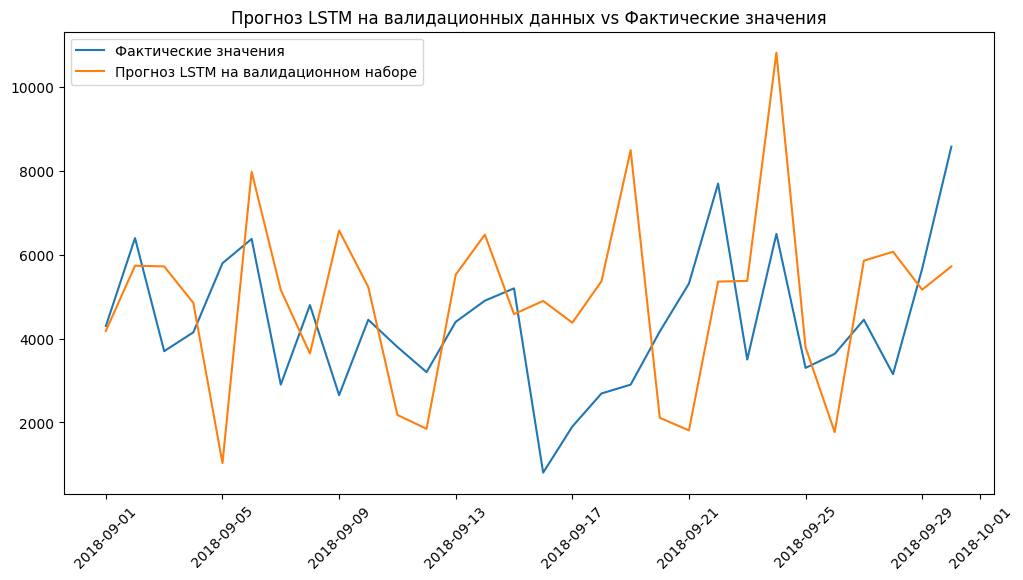

In [28]:
# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_val_original.index, y_val_original.values, label='Фактические значения')
plt.plot(y_val_original.index, y_val_pred_lstm, label='Прогноз LSTM на валидационном наборе')
plt.xticks(rotation=45)
plt.title('Прогноз LSTM на валидационных данных vs Фактические значения')
plt.legend()
plt.show()


In [29]:
y_val_original.describe()

count     30.00
mean    4376.60
std     1685.83
min      800.00
25%     3225.00
50%     4235.00
75%     5286.25
max     8580.00
dtype: float64

## SARIMAX
### Подготовка данных
<a id='SARIMAX-подготовка-данных'></a> 
[К содержанию](#К-содержанию)

In [30]:
# загружаем ряд с несдвинутым целевым признаком и разбиваем на тренировочную, валидационную и тестовую выборки
y_train_sarimax = data_fund_added_agg.loc[data_fund_added_agg.index < val_month, 'full_sum'].copy().asfreq('D')
y_val_sarimax = data_fund_added_agg.loc[data_fund_added_agg.index.strftime('%Y-%m') == val_month, 'full_sum'].copy().asfreq('D')
y_test_sarimax = data_fund_added_agg.loc[data_fund_added_agg.index.strftime('%Y-%m') == test_month, 'full_sum'].copy().asfreq('D')


display(y_train_sarimax.shape,
        y_val_sarimax.shape,
        y_test_sarimax.shape)

print("Первая тренировочная дата:", y_train_sarimax.index.min().date())
print("Последняя тренировочная дата:", y_train_sarimax.index.max().date())
print("Первая валидационная дата:", y_val_sarimax.index.min().date())
print("Последняя валидационная дата:", y_val_sarimax.index.max().date())
print("Первая тестовая дата:", y_test_sarimax.index.min().date())

(316,)

(30,)

(19,)

Первая тренировочная дата: 2017-10-20
Последняя тренировочная дата: 2018-08-31
Первая валидационная дата: 2018-09-01
Последняя валидационная дата: 2018-09-30
Первая тестовая дата: 2018-10-01


<a id='SARIMAX-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [31]:
# функция кросс-валидаци для подбора гиперпараметров SARIMAX
def cross_validate_sarima(data, order, seasonal_order, n_splits=n_splits):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmse_scores = []
    smape_scores = []
    best_model = None
    best_rmse = np.inf
    
    data = data.asfreq('D')
    
    for train_index, test_index in tscv.split(data):
        train = data.iloc[train_index]
        test = data.iloc[test_index]
        
        model_sarimax = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model_sarimax.fit(disp=False, 
                            maxiter=1000,
                            optim_score='harvey',
                            method='powell',
                            cov_type='robust')
        
        # делаем прогноз
        forecast = results.get_forecast(steps=len(test))
        predicted_mean = forecast.predicted_mean
        predicted_mean = predicted_mean.clip(lower=0) #отрицательные меняем на ноль

        # cчитаем RMSE
        current_rmse = np.sqrt(mean_squared_error(test, predicted_mean))
        rmse_scores.append(current_rmse)
        
        # cчитаем SMAPE
        current_smape = smape(test, predicted_mean)
        smape_scores.append(current_smape)

        # сохраняем лучший вариант метрики и модели
        if current_rmse < best_rmse:
            best_rmse = current_rmse
            #best_smape = current_smape
            best_model = results
    
    # dозвращаем средние значения RMSE и SMAPE
    return np.nanmean(rmse_scores), np.nanmean(smape_scores), best_model

# задаем наборы гиперпараметров для SARIMAX
param_sets = [
    
    ((1, 1, 0), (0, 1, 1, 7)),  # упрощенная модель
    ((0, 1, 1), (0, 1, 1, 7)),  # базовый вариант
    ((1, 0, 0), (1, 1, 0, 7)),  # AR-структура
    ((0, 1, 2), (0, 1, 1, 7)),  # с увеличенным MA
    ((0, 1, 1), (1, 1, 1, 7)),  # с сезонным AR
    ((1, 1, 7), (0, 0, 0, 0)),  # ручной вариант
    ((1, 1, 2), (0, 0, 0, 0))   # ручной вариант 2
]

# перебор параметров
best_model_overall_sarimax = None
best_rmse_overall_sarimax = np.inf
best_smape_overall_sarimax = np.inf

for param in param_sets:
    
    average_rmse_sarimax, average_smape_sarimax, best_model_sarimax = cross_validate_sarima(
        y_train_sarimax,
        param[0],
        param[1]
    )
    print(f"Средние значения метрик для набора параметров {param}: "
          f"RMSE - {average_rmse_sarimax:.2f} SMAPE: {average_smape_sarimax:.2f}")

    if average_rmse_sarimax < best_rmse_overall_sarimax:
        best_rmse_overall_sarimax = average_rmse_sarimax
        best_model_overall_sarimax = best_model_sarimax
        best_smape_overall_sarimax = average_smape_sarimax
    

Средние значения метрик для набора параметров ((1, 1, 0), (0, 1, 1, 7)): RMSE - 2144.56 SMAPE: 100.35
Средние значения метрик для набора параметров ((0, 1, 1), (0, 1, 1, 7)): RMSE - 371128553488.57 SMAPE: 86.79
Средние значения метрик для набора параметров ((1, 0, 0), (1, 1, 0, 7)): RMSE - 1755.46 SMAPE: 88.63
Средние значения метрик для набора параметров ((0, 1, 2), (0, 1, 1, 7)): RMSE - 439985196742.24 SMAPE: 86.36
Средние значения метрик для набора параметров ((0, 1, 1), (1, 1, 1, 7)): RMSE - 1816.83 SMAPE: 86.50
Средние значения метрик для набора параметров ((1, 1, 7), (0, 0, 0, 0)): RMSE - 1604.26 SMAPE: 78.50
Средние значения метрик для набора параметров ((1, 1, 2), (0, 0, 0, 0)): RMSE - 1557.72 SMAPE: 77.87


In [32]:
y_train_sarimax.describe()

count    316.00
mean    2502.28
std     2486.18
min        0.00
25%       50.00
50%     2200.00
75%     4450.75
max     8796.00
Name: full_sum, dtype: float64

In [33]:
# переобучаем лучшую модель на всем датасете инкрементально, чтобы использовать потом валидационные и тестовые прогнозы

# забираем всю последовательность для обучения и прогноза 
y_full_sarimax = data_fund_added_agg.loc[:, 'full_sum'].copy().asfreq('D')

# создаем пустую серию для хранения прогнозов
sarima_forecast = pd.Series(index=y_full_sarimax.index, dtype=float)

# определяем минимальный размер выборки для начала обучения SARIMAX
min_full_size = 10

# заполняем начальные значения средними про предыдущим значениям
sarima_forecast.iloc[0] = y_full_sarimax.iloc[0]  # первое значение как есть
 
for i in range(1, min_full_size):
    sarima_forecast.iloc[i] = y_full_sarimax.iloc[:i].mean()

# задаем параметры модели
order = best_model_overall_sarimax.model.order
seasonal_order = best_model_overall_sarimax.model.seasonal_order

# запускаем обучение и прогнозирование, начиная с min_full_size
for i in range(min_full_size, len(y_full_sarimax)):
    # используем все доступные данные для обучения
    train_series = y_full_sarimax.iloc[:i].asfreq('D')
    
    model_sarimax_full = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False,
          maxiter=1000,
          optim_score='harvey',
          method='powell',
          cov_type='robust')
    
    # прогнозируем следующее значение и заменяем отрицательные значения на 0
    forecast = model_sarimax_full.get_forecast(steps=1)
    predicted_value = forecast.predicted_mean.item()  # достаем предсказанное значение
    predicted_value = max(predicted_value, 0)

    sarima_forecast.iloc[i] = predicted_value

# обнуляем первые значения, чтобы они не влияли на CatBoost
sarima_forecast.iloc[:min_full_size] = np.nan

print(f'Лучшая модель с RMSE {best_rmse_overall_sarimax:.2f} и параметрами {order, seasonal_order} обучена на всех данных')
print("Первые 15 прогнозов:")
display(sarima_forecast.head(15))

Лучшая модель с RMSE 1557.72 и параметрами ((1, 1, 2), (0, 0, 0, 0)) обучена на всех данных
Первые 15 прогнозов:


2017-10-20      NaN
2017-10-21      NaN
2017-10-22      NaN
2017-10-23      NaN
2017-10-24      NaN
2017-10-25      NaN
2017-10-26      NaN
2017-10-27      NaN
2017-10-28      NaN
2017-10-29      NaN
2017-10-30     0.00
2017-10-31     0.00
2017-11-01     0.00
2017-11-02     0.00
2017-11-03   600.00
Freq: D, dtype: float64

<a id='SARIMAX-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [34]:
display(y_val_sarimax.head(1))
y_val_sarimax.tail(1)

2018-09-01   6610.00
Freq: D, Name: full_sum, dtype: float64

2018-09-30   5670.00
Freq: D, Name: full_sum, dtype: float64

In [35]:
# отбираем прогнозы и реальные значения для валидации со сдвигом на 1 значение назад, для корректоного сравнения с другими моделями
y_val_sarimax = data_fund_added_agg.shift(-1).loc[data_fund_added_agg.index.strftime('%Y-%m') == val_month, 'full_sum'].copy().asfreq('D')

y_val_pred_sarimax = sarima_forecast.shift(-1).loc[sarima_forecast.index.strftime('%Y-%m') == val_month].copy().asfreq('D')
display(y_val_pred_sarimax.head(1),
        y_val_pred_sarimax.tail(1))

y_val_pred_sarimax.describe()

2018-09-01   4122.50
Freq: D, dtype: float64

2018-09-30   4384.76
Freq: D, dtype: float64

count     30.00
mean    4165.18
std      346.85
min     3383.27
25%     4064.40
50%     4237.61
75%     4392.53
max     4807.90
dtype: float64

Метрика RMSE на валидационных данных: 1721.70
Метрика SMAPE на валидационных данных: 32.18


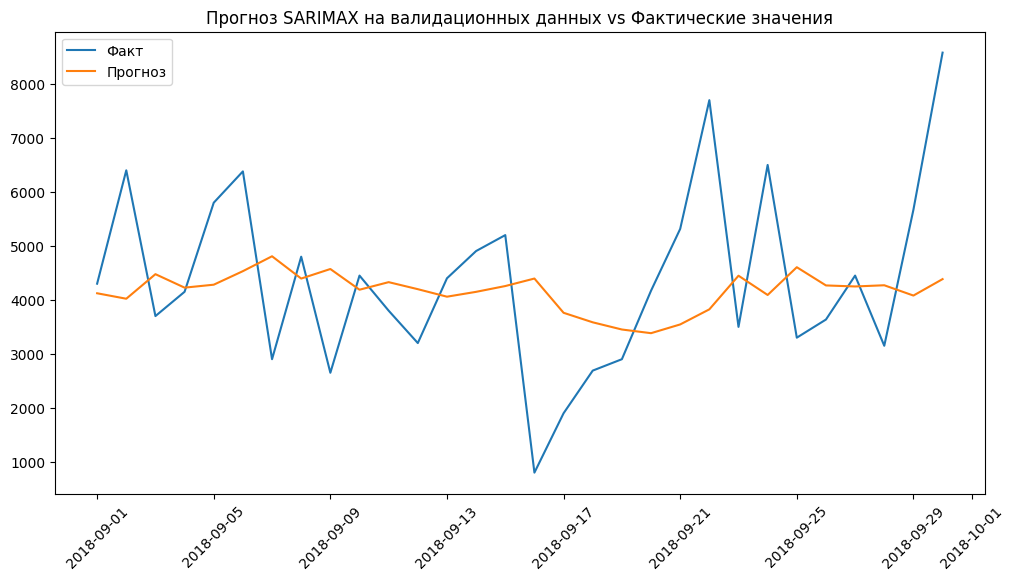

In [36]:
# считаем метрики RMSE и SMAPE
rmse_val_sarimax = np.sqrt(mean_squared_error(y_val_sarimax, y_val_pred_sarimax))
smape_val_sarimax = smape(y_val_sarimax, y_val_pred_sarimax)

print(f"Метрика RMSE на валидационных данных: {rmse_val_sarimax:.2f}")
print(f"Метрика SMAPE на валидационных данных: {smape_val_sarimax:.2f}")

# строим график прогноза
plt.figure(figsize=(12, 6))
plt.plot(y_val_sarimax, label='Факт')
plt.plot(y_val_pred_sarimax, label='Прогноз')
plt.title('Прогноз SARIMAX на валидационных данных vs Фактические значения')
plt.xticks(rotation=45)
plt.legend()
plt.show()

<a id='Catboost-подготовка-данных'></a> 
## Catboost (+sarimax)
### Подготовка данных
[К содержанию](#К-содержанию)


In [37]:
# добавляем прогноз sarimax как признак в датасет + сдвигаем его на 1 назад, чтобы соответствовать временным точкам прочих признаков 

X_train['sarima_forecast'] = sarima_forecast.shift(-1).reindex(X_train.index)
#X_train = X_train.dropna()
X_train.head(5)

,category_1,category_2,category_3,category_4,category_5,category_6,category_7,provider_1.0,provider_3.0,provider_4.0,provider_5.0,signup,count_payments,avg_payment,median_payment,min_payment,max_payment,day_of_week,week_number,rolling_avg_payment,lag_1_full_sum,lag_2_full_sum,lag_3_full_sum,lag_4_full_sum,lag_5_full_sum,lag_6_full_sum,lag_7_full_sum,sarima_forecast
2017-10-27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,4,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,300.00,NaN
2017-10-28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,5,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-10-29,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,6,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-10-30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,0,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-10-31,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,1,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


<a id='Catboost-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [38]:
# подготовим обучение
cat_features = ['day_of_week', 'week_number']

tss = TimeSeriesSplit(n_splits = n_splits)

# итоговый пайплайн
pipe_final = Pipeline([
    ('model', CatBoostRegressor(
        silent=True,
        random_state=RANDOM_STATE,
        cat_features=cat_features))
])

# сетка гиперпараметров
param_grid = [
    # CatBoostRegressor
    {
        'model__iterations': [100,200,500],
        'model__depth': [2,5,7],
        'model__learning_rate': [0.1,0.001],
        'model__l2_leaf_reg': [2],
        #'model__subsample': [0.8],
        'model__loss_function': ['RMSE'], # 'MAE', 'Quantile:alpha=0.8'],
        'model__max_bin': [256],
        'model__random_strength': [1],
        'model__early_stopping_rounds':[10]
        
    }
]

In [39]:
# полный перебор гиперпараметров с помощью GridSearchCV
grid_search = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=tss,
    scoring={'neg_mean_squared_error': 'neg_mean_squared_error', 'smape': smape_scorer},
    refit='neg_mean_squared_error',
    n_jobs=-1,
    error_score='raise'
)

# обучение модели
model = grid_search.fit(X_train, y_train)

# выгружаем метрики
best_score_neg_mse = grid_search.best_score_
best_score_rmse = round(np.sqrt(-best_score_neg_mse), 3)
best_score_smape = round(-grid_search.cv_results_['mean_test_smape'][grid_search.best_index_], 3)  # Инверсия знака

# выводим результаты
print(f'Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_rmse}')
print(f'Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_smape}')
print(f'Параметры лучшей модели: {grid_search.best_params_}')

Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: 1491.732
Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: 78.863
Параметры лучшей модели: {'model__depth': 5, 'model__early_stopping_rounds': 10, 'model__iterations': 500, 'model__l2_leaf_reg': 2, 'model__learning_rate': 0.1, 'model__loss_function': 'RMSE', 'model__max_bin': 256, 'model__random_strength': 1}


In [40]:
# берем модель CatBoostRegressor из пайплайна
catboost_model = model.best_estimator_.named_steps["model"]

# получаем важность признаков
feature_importances = catboost_model.get_feature_importance()
feature_names = catboost_model.feature_names_

# преобразовываем в DataFrame, сортируем и выводим
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                Feature  Importance
11               signup        9.86
24       lag_5_full_sum        8.26
26       lag_7_full_sum        7.26
12       count_payments        6.82
13          avg_payment        6.37
22       lag_3_full_sum        6.04
7          provider_1.0        5.58
21       lag_2_full_sum        5.38
2            category_3        5.33
27      sarima_forecast        5.26
25       lag_6_full_sum        5.08
20       lag_1_full_sum        4.49
10         provider_5.0        4.41
19  rolling_avg_payment        4.27
23       lag_4_full_sum        3.98
15          min_payment        3.10
14       median_payment        2.44
16          max_payment        2.25
18          week_number        2.04
17          day_of_week        1.07
9          provider_4.0        0.45
8          provider_3.0        0.24
1            category_2        0.00
6            category_7        0.00
5            category_6        0.00
4            category_5        0.00
3            category_4     

<a id='Catboost-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [41]:
# добавляем прогнозы sarimax в валидационный датафрейм
X_val['sarima_forecast'] = sarima_forecast.shift(-1).reindex(X_val.index)
X_val.head(5)

,category_1,category_2,category_3,category_4,category_5,category_6,category_7,provider_1.0,provider_3.0,provider_4.0,provider_5.0,signup,count_payments,avg_payment,median_payment,min_payment,max_payment,day_of_week,week_number,rolling_avg_payment,lag_1_full_sum,lag_2_full_sum,lag_3_full_sum,lag_4_full_sum,lag_5_full_sum,lag_6_full_sum,lag_7_full_sum,sarima_forecast
2018-09-01,0.00,0.00,25.00,0.00,0.00,0.00,0.00,23.00,0.00,0.00,2.00,25.00,25,264.40,200.00,30.00,1000.00,5,1,467.03,4200.00,10750.00,2950.00,3920.00,3236.00,2350.00,5000.00,4122.50
2018-09-02,0.00,0.00,10.00,0.00,0.00,0.00,0.00,10.00,0.00,0.00,0.00,10.00,10,430.00,300.00,100.00,1000.00,6,1,365.53,6610.00,4200.00,10750.00,2950.00,3920.00,3236.00,2350.00,4021.26
2018-09-03,0.00,0.00,16.00,0.00,0.00,0.00,0.00,16.00,0.00,0.00,0.00,15.00,16,400.00,400.00,100.00,1000.00,0,1,347.20,4300.00,6610.00,4200.00,10750.00,2950.00,3920.00,3236.00,4476.38
2018-09-04,0.00,0.00,13.00,0.00,0.00,0.00,0.00,13.00,0.00,0.00,0.00,13.00,13,284.62,200.00,100.00,1000.00,1,1,415.00,6400.00,4300.00,6610.00,4200.00,10750.00,2950.00,3920.00,4226.68
2018-09-05,0.00,0.00,15.00,0.00,0.00,0.00,0.00,13.00,0.00,0.00,2.00,14.00,15,276.67,200.00,100.00,1000.00,2,1,342.31,3700.00,6400.00,4300.00,6610.00,4200.00,10750.00,2950.00,4281.25


Метрика RMSE  на валидационном наборе: 1556.55
Метрика SMAPE на валидационном наборе: 28.44


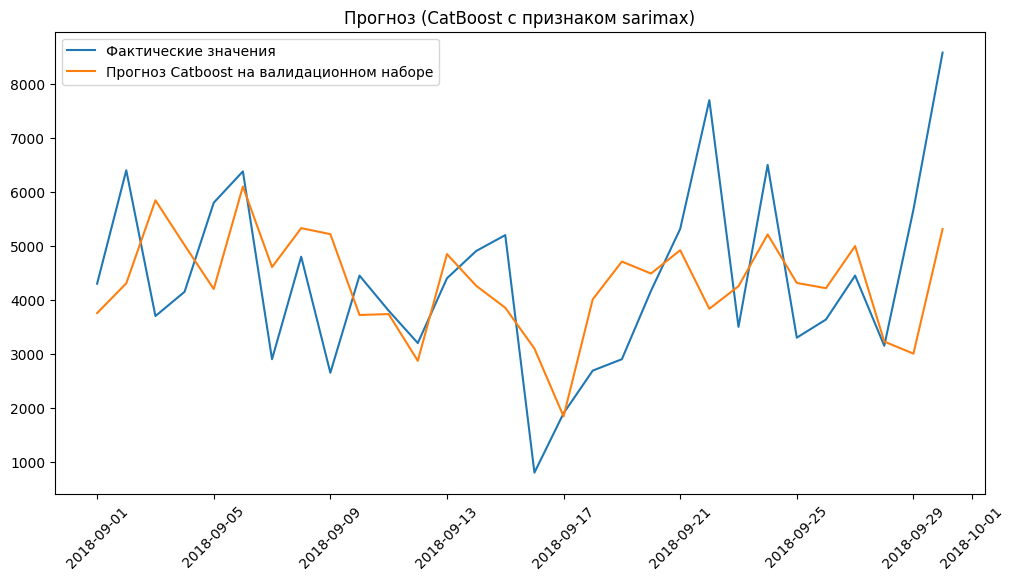

In [42]:
# тестирование catboost на валидационной выборке

# переобучаем лучшую модель на всем тренировочном наборе
final_model_cb = grid_search.best_estimator_
final_model_cb.fit(X_train, y_train)

# делаем прогноз и считаем метрики RMSE и SMAPE на валидационном наборе
y_val_pred_cb = np.round(final_model_cb.predict(X_val), decimals=2)

rmse_val_cb = np.sqrt(mean_squared_error(y_val, y_val_pred_cb))
smape_metrics_val_cb = smape(y_val, y_val_pred_cb)

# выводим метрики
print(f'Метрика RMSE  на валидационном наборе: {rmse_val_cb:.2f}')
print(f'Метрика SMAPE на валидационном наборе: {smape_metrics_val_cb:.2f}')

# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val.values, label='Фактические значения')
plt.plot(y_val.index, y_val_pred_cb, label='Прогноз Catboost на валидационном наборе')
plt.xticks(rotation=45)
plt.title('Прогноз (CatBoost c признаком sarimax)')
plt.legend()
plt.show()


<a id='Подбор-модели-ансамбля-прогнозов-на-валидационной-выборке'></a> 
## Подбор модели ансамбля прогнозов на валидационной выборке
[К содержанию](#К-содержанию)

Сверим размерности и временые ряды истинных валидационных значений и предсказаний разных моделей:

In [43]:
#LSTM
display(y_val_original.shape)
display(y_val_original.head(3),
        y_val_original.tail(3))

display(y_val_pred_lstm.shape)
display(y_val_pred_lstm[:3],
        y_val_pred_lstm[-3:])

(30,)

2018-09-01   4300.00
2018-09-02   6400.00
2018-09-03   3700.00
dtype: float32

2018-09-28   3150.00
2018-09-29   5670.00
2018-09-30   8580.00
dtype: float32

(30,)

array([4183.87, 5740.31, 5723.72], dtype=float32)

array([6073.99, 5168.59, 5722.65], dtype=float32)

In [44]:
#SARIMAX
# отбираем и реальные значения и прогнозы со сдвигом на 1 день
y_val_sarimax = data_fund_added_agg.shift(-1).loc[data_fund_added_agg.index.strftime('%Y-%m') == val_month, 'full_sum'].copy().asfreq('D')
y_val_pred_sarimax = sarima_forecast.shift(-1).loc[sarima_forecast.index.strftime('%Y-%m') == val_month].copy().asfreq('D')

display(y_val_sarimax.shape)
display(y_val_sarimax.head(3),
        y_val_sarimax.tail(3))

display(y_val_pred_sarimax.shape)
display(y_val_pred_sarimax.head(3),
        y_val_pred_sarimax.tail(3))



(30,)

2018-09-01   4300.00
2018-09-02   6400.00
2018-09-03   3700.00
Freq: D, Name: full_sum, dtype: float64

2018-09-28   3150.00
2018-09-29   5670.00
2018-09-30   8580.00
Freq: D, Name: full_sum, dtype: float64

(30,)

2018-09-01   4122.50
2018-09-02   4021.26
2018-09-03   4476.38
Freq: D, dtype: float64

2018-09-28   4270.83
2018-09-29   4080.09
2018-09-30   4384.76
Freq: D, dtype: float64

In [45]:
#Catboost
display(y_val.shape)
display(y_val.head(3),
        y_val.tail(3))

display(y_val_pred_cb.shape)
display(y_val_pred_cb[:3],
        y_val_pred_cb[-3:])


(30,)

2018-09-01   4300.00
2018-09-02   6400.00
2018-09-03   3700.00
Name: target_shifted, dtype: float64

2018-09-28   3150.00
2018-09-29   5670.00
2018-09-30   8580.00
Name: target_shifted, dtype: float64

(30,)

array([3754.92, 4306.99, 5844.6 ])

array([3227.82, 3004.06, 5311.54])

In [46]:
forecasts_val = y_val.to_frame(name='y_actual') 
forecasts_val['forecast_lstm'] = pd.Series(y_val_pred_lstm, index=y_val.index)
forecasts_val = forecasts_val.join(y_val_pred_sarimax.rename('forecast_sarimax'))
forecasts_val['forecast_catboost'] = pd.Series(y_val_pred_cb, index=y_val.index)

display(forecasts_val.isna().sum().sum())
display(forecasts_val.head(2),
        forecasts_val.tail(2))


0

,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2018-09-01,4300.00,4183.87,4122.50,3754.92
2018-09-02,6400.00,5740.31,4021.26,4306.99


,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2018-09-29,5670.00,5168.59,4080.09,3004.06
2018-09-30,8580.00,5722.65,4384.76,5311.54


In [47]:
# сверим метрики
forecast_columns = forecasts_val.columns[1:]
for column in forecast_columns:
    print(f"Модель: {column}")
    print(f"Метрика RMSE на валидационном наборе: {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val[column])):.2f}")
    print(f"Метрика SMAPE на валидационном наборе: {smape(forecasts_val['y_actual'], forecasts_val[column]):.2f}\n")


Модель: forecast_lstm
Метрика RMSE на валидационном наборе: 2516.30
Метрика SMAPE на валидационном наборе: 49.76

Модель: forecast_sarimax
Метрика RMSE на валидационном наборе: 1721.70
Метрика SMAPE на валидационном наборе: 32.18

Модель: forecast_catboost
Метрика RMSE на валидационном наборе: 1556.55
Метрика SMAPE на валидационном наборе: 28.44



Взвесим прогнозы тремя способами - через среднее, линейную регрессию и нейросеть:

In [48]:
# считаем средние прогнозы
forecasts_val['forecast_mean'] = forecasts_val[forecast_columns].mean(axis=1)

forecasts_val.head()

,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost,forecast_mean
2018-09-01,4300.00,4183.87,4122.50,3754.92,4020.43
2018-09-02,6400.00,5740.31,4021.26,4306.99,4689.52
2018-09-03,3700.00,5723.72,4476.38,5844.60,5348.23
2018-09-04,4150.00,4852.84,4226.68,5013.48,4697.67
2018-09-05,5800.00,1026.41,4281.25,4200.69,3169.45


In [49]:
print(f"Метрика RMSE на валидационном наборе по средним прогнозам 3-х моделей: {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_mean'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по средним прогнозам 3-х моделей: {smape(forecasts_val['y_actual'], forecasts_val['forecast_mean']):.2f}\n")

Метрика RMSE на валидационном наборе по средним прогнозам 3-х моделей: 1668.27
Метрика SMAPE на валидационном наборе по средним прогнозам 3-х моделей: 31.33



In [50]:
# обучим линейную регрессию (ridge) для взвешивания прогнозов трех моделей

# выбираем прогнозы моделей как фичи
X_meta = forecasts_val[['forecast_lstm', 'forecast_sarimax', 'forecast_catboost']]
y_meta = forecasts_val['y_actual']

# обучаем Ridge-регрессию с коэффициентом регуляризации
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_meta, y_meta)

# делаем предсказание на валидационной же выборке
forecasts_val['forecast_ridge'] = ridge_model.predict(X_meta)

# выводим коэффициенты
print("Коэффициенты Ridge:", ridge_model.coef_)
print("Свободный член (intercept):", ridge_model.intercept_)

Коэффициенты Ridge: [ 0.02144096 -0.70846081  0.74067604]
Свободный член (intercept): 4034.2573437421897


In [51]:
print(f"Метрика RMSE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_ridge'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): {smape(forecasts_val['y_actual'], forecasts_val['forecast_ridge']):.2f}\n")

Метрика RMSE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): 1510.86
Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей (веса по линейной регрессии): 28.07



In [52]:
# обучим простую нейросеть для взвешивания прогнозов трех моделей

# преобразуем прогнозы на валидацинной выборке в тензоры PyTorch
X_meta_tensor = torch.tensor(X_meta.values, dtype=torch.float32)
y_meta_tensor = torch.tensor(y_meta.values, dtype=torch.float32)

# задаем модель нейросети
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc = nn.Linear(3, 1)  # 3 входных признака-прогноза

    def forward(self, x):
        return self.fc(x)

# инициализируем модель
model_meta = SimpleNN()

# определяем функцию потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model_meta.parameters(), lr=0.001)

# обучаем модель
num_epochs = 500
for epoch in range(num_epochs):
    # прямой проход
    outputs = model_meta(X_meta_tensor).squeeze()
    loss = criterion(outputs, y_meta_tensor)

    # обратный проход и оптимизация
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:  # печатаем каждый 50-й шаг
        print(f"Эпоха [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# прогнозируем на валидационных данных
forecasts_val['forecast_nn'] = model_meta(X_meta_tensor).detach().numpy()

# выводим коэффициенты и смещение
print("Коэффициенты (веса):", model_meta.fc.weight)
print("Смещение (bias):", model_meta.fc.bias)

Эпоха [50/500], Loss: 5868568.0000
Эпоха [100/500], Loss: 4653729.0000
Эпоха [150/500], Loss: 4112680.5000
Эпоха [200/500], Loss: 3897722.7500
Эпоха [250/500], Loss: 3803213.5000
Эпоха [300/500], Loss: 3741322.2500
Эпоха [350/500], Loss: 3685225.5000
Эпоха [400/500], Loss: 3629327.5000
Эпоха [450/500], Loss: 3573216.5000
Эпоха [500/500], Loss: 3517350.5000
Коэффициенты (веса): Parameter containing:
tensor([[ 0.4730,  0.7218, -0.2482]], requires_grad=True)
Смещение (bias): Parameter containing:
tensor([0.0622], requires_grad=True)


In [53]:
print(f"Метрика RMSE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_nn'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): {smape(forecasts_val['y_actual'], forecasts_val['forecast_nn']):.2f}\n")

Метрика RMSE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): 1875.16
Метрика SMAPE на валидационном наборе по прогнозам 3-х моделей(веса по нейросети): 35.48



<a id='Тестирование-ансамбля-прогнозов-на-тестовой-выборке'></a> 
## Тестирование ансамбля прогнозов на тестовой выборке
[К содержанию](#К-содержанию)

In [54]:
# делаем тестовые прогнозы от модели LSTM

# добавляем последние time_steps строк из валидационного набора в тестовый
# (тк они нужны для запуска первого прогноза, чтобы не тратить на это тестовые данные)
X_test_full = pd.concat([X_val_prepared.tail(time_steps), X_test_prepared], axis=0)
y_test_full = pd.concat([y_val_scaled.tail(time_steps), y_test_scaled], axis=0)

# создаем последовательности для тестового набора
X_seq_test, y_seq_test = create_sequences(X_test_full.values, y_test_full.values, time_steps)

# преобразуем в тензоры
X_test_tensor = torch.tensor(X_seq_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_seq_test, dtype=torch.float32).view(-1, 1)

# делаем прогноз
model_lstm.eval()
with torch.no_grad():
    y_pred = model_lstm(X_test_tensor)

# разворачиваем масштабированные данные
y_test_original = np.round(scaler_y.inverse_transform(y_test_tensor.numpy()).flatten(), decimals=2)
y_test_pred_lstm = np.round(scaler_y.inverse_transform(y_pred.numpy()).flatten(), decimals=2)

# преобразуем y_test_original в Series с правильными временныеми индексами
y_test_original = pd.Series(y_test_original, index=y_test_full.index[-len(y_test_original):])

# считаем метрики
rmse_test_lstm = np.sqrt(mean_squared_error(y_test_original, y_test_pred_lstm))
smape_test_lstm = smape(y_test_original, y_test_pred_lstm)

print(f'Метрика RMSE на финальных тестовых данных: {rmse_test_lstm:.3f}')
print(f'Метрика SMAPE на финальных тестовых данных: {smape_test_lstm:.4f}')

Метрика RMSE на финальных тестовых данных: 1938.575
Метрика SMAPE на финальных тестовых данных: 41.1438


In [55]:
# отбираем тестовые прогнозы от модели SARIMAX

# отбираем прогнозы и реальные значения для тестирования со сдвигом на 1 значение назад, для корректоного сравнения с другими моделями
y_test_sarimax = data_fund_added_agg.shift(-1).loc[data_fund_added_agg.index.strftime('%Y-%m') == test_month, 'full_sum'].copy().asfreq('D')
y_test_pred_sarimax = sarima_forecast.shift(-1).loc[sarima_forecast.index.strftime('%Y-%m') == test_month].copy().asfreq('D')

y_test_sarimax = y_test_sarimax.dropna()
y_test_pred_sarimax = y_test_pred_sarimax.dropna()

# считаем метрики RMSE и SMAPE
rmse_test_sarimax = np.sqrt(mean_squared_error(y_test_sarimax, y_test_pred_sarimax))
smape_test_sarimax = smape(y_test_sarimax, y_test_pred_sarimax)

print(f'Метрика RMSE на финальных тестовых данных: {rmse_test_sarimax:.3f}')
print(f'Метрика SMAPE на финальных тестовых данных: {smape_test_sarimax:.4f}')

Метрика RMSE на финальных тестовых данных: 1782.752
Метрика SMAPE на финальных тестовых данных: 40.9557


In [56]:
# делаем тестовые прогнозы от модели Catboost

# добавляем прогнозы sarimax в тестовый датафрейм, сдвинув ихз на -1 для соответствия с признаками catboost
X_test['sarima_forecast'] = sarima_forecast.shift(-1).reindex(X_test.index)

# делаем прогноз и считаем метрики RMSE и SMAPE на тестовом наборе
y_test_pred_cb = np.round(final_model_cb.predict(X_test), decimals=2)

rmse_test_cb = np.sqrt(mean_squared_error(y_test, y_test_pred_cb))
smape_metrics_test_cb = smape(y_test, y_test_pred_cb)

print(f'Метрика RMSE  на тестовом наборе: {rmse_test_cb:.2f}')
print(f'Метрика SMAPE на тестовом наборе: {smape_metrics_test_cb:.2f}')


Метрика RMSE  на тестовом наборе: 1400.79
Метрика SMAPE на тестовом наборе: 28.62


In [57]:
# собираем тестовые прогнозы в датафрейм
forecasts_test = y_test.to_frame(name='y_actual') 
forecasts_test['forecast_lstm'] = pd.Series(y_test_pred_lstm, index=y_test.index)
forecasts_test = forecasts_test.join(y_test_pred_sarimax.rename('forecast_sarimax'))
forecasts_test['forecast_catboost'] = pd.Series(y_test_pred_cb, index=y_test.index)

display(forecasts_test.isna().sum().sum())
display(forecasts_test.head(2),
        forecasts_test.tail(2))


0

,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2018-10-01,4030.00,5659.91,5050.72,4742.19
2018-10-02,7100.00,8195.48,4688.31,5158.99


,y_actual,forecast_lstm,forecast_sarimax,forecast_catboost
2018-10-17,4000.00,2310.60,3693.63,3873.18
2018-10-18,20.00,4440.86,3785.35,4220.42


In [58]:
# предсказание ансамблем со взвешиванием линейной регрессией

# выбираем прогнозы моделей как фичи
X_meta_test = forecasts_test[['forecast_lstm', 'forecast_sarimax', 'forecast_catboost']]
y_meta_test = forecasts_test['y_actual']

forecasts_test['forecast_ridge'] = ridge_model.predict(X_meta_test)

print(f"Метрика RMSE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): {np.sqrt(mean_squared_error(forecasts_test['y_actual'], forecasts_test['forecast_ridge'])):.2f}")
print(f"Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): {smape(forecasts_test['y_actual'], forecasts_test['forecast_ridge']):.2f}\n")

Метрика RMSE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): 1479.52
Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей (веса по линейной регрессии): 29.88



In [59]:
# предсказание ансамблем с взвешиванием нейросетью

# преобразуем данные в тензоры PyTorch
X_meta_test_tensor = torch.tensor(X_meta_test.values, dtype=torch.float32)
y_meta_test_tensor = torch.tensor(y_meta_test.values, dtype=torch.float32)

# прогнозируем на тестовых данных
forecasts_test['forecast_nn'] = model_meta(X_meta_test_tensor).detach().numpy()

print(f"Метрика RMSE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): {np.sqrt(mean_squared_error(forecasts_test['y_actual'], forecasts_test['forecast_nn'])):.2f}")
print(f"Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): {smape(forecasts_test['y_actual'], forecasts_test['forecast_nn']):.2f}\n")

Метрика RMSE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): 1650.53
Метрика SMAPE на тестовом наборе по прогнозам 3-х моделей(веса по нейросети): 38.31



С учетом небольшого датасета  для обучения модели для взвешивания прогноза, результат ансамбля получился хуже чем лучшая одиночная модель catboost, однако оставим ансамбли для тестирования на большом датасете.  
Ниже для наглядности приведем прогнозы лучшей из отдельных моделей (catboost) и лучшего ансамбля по прогнозам трех моделей с весами, посчитанными ridge-регрессией.

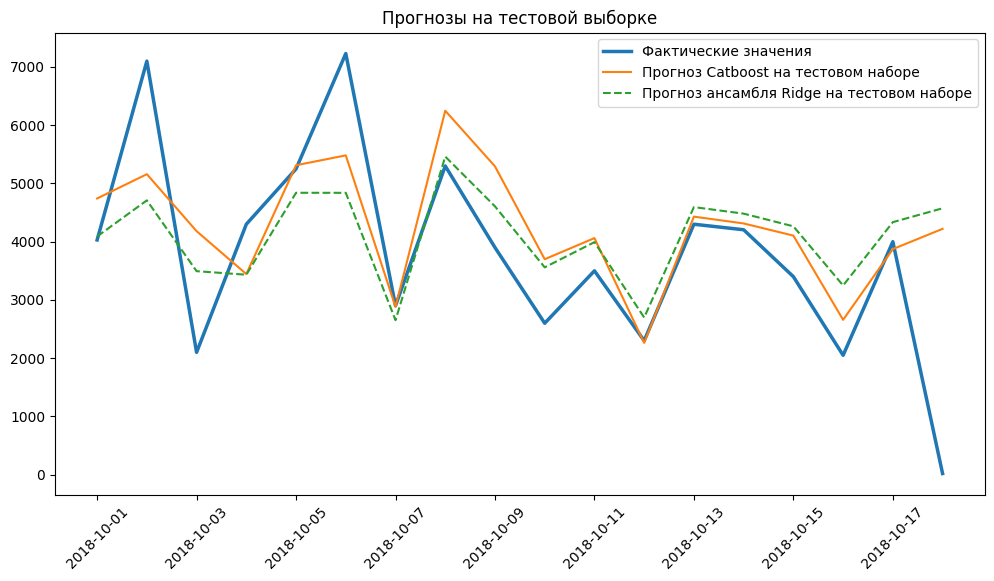

In [60]:
# посмотрим тестовые прогнозы на графике 
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test.values, label='Фактические значения', linewidth=2.5)
#plt.plot(y_test.index, y_test_pred_lstm, label='Прогноз LSTM на тестовом наборе')
#plt.plot(y_test.index, y_test_pred_sarimax, label='Прогноз SARIMAX на тестовом наборе')
plt.plot(y_test.index, y_test_pred_cb, label='Прогноз Catboost на тестовом наборе')
plt.plot(y_test.index, forecasts_test['forecast_ridge'], label='Прогноз ансамбля Ridge на тестовом наборе', linestyle='--')

plt.xticks(rotation=45)
plt.title('Прогнозы на тестовой выборке')
plt.legend()
plt.show()
